<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1803 | Val: 440 | Test: 284


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-50] Epoch   1/100 | LR: 3.77e-04 | train loss 1.0871 acc 0.544 | val loss 0.9984 acc 0.711 *


[ResNet-50] Epoch   2/100 | LR: 3.77e-04 | train loss 0.6683 acc 0.704 | val loss 0.5158 acc 0.802 *


[ResNet-50] Epoch   3/100 | LR: 3.77e-04 | train loss 0.5562 acc 0.743 | val loss 0.5657 acc 0.802


[ResNet-50] Epoch   4/100 | LR: 3.77e-04 | train loss 0.4971 acc 0.794 | val loss 0.5526 acc 0.789


...

[ResNet-50] Epoch  17/100 | LR: 3.77e-05 | train loss 0.1186 acc 0.946 | val loss 0.4967 acc 0.870


[ResNet-50] Epoch  18/100 | LR: 3.77e-05 | train loss 0.0923 acc 0.957 | val loss 0.4925 acc 0.864


[ResNet-50] Epoch  19/100 | LR: 3.77e-05 | train loss 0.0572 acc 0.972 | val loss 0.5006 acc 0.875


[ResNet-50] Epoch  20/100 | LR: 3.77e-05 | train loss 0.0470 acc 0.979 | val loss 0.5113 acc 0.875


[ResNet-50] Epoch  21/100 | LR: 3.77e-05 | train loss 0.0508 acc 0.976 | val loss 0.5116 acc 0.875

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 21.

[ResNet-50] Restored best checkpoint (val loss = 0.4368)


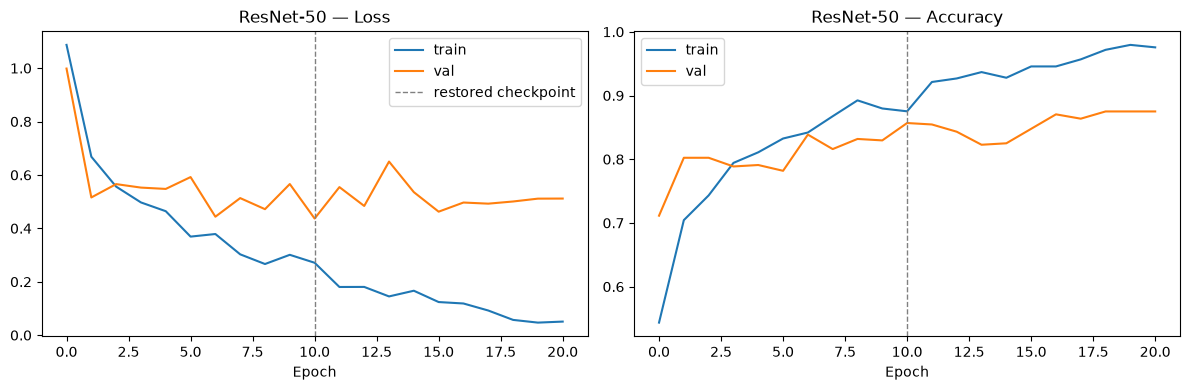

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.870


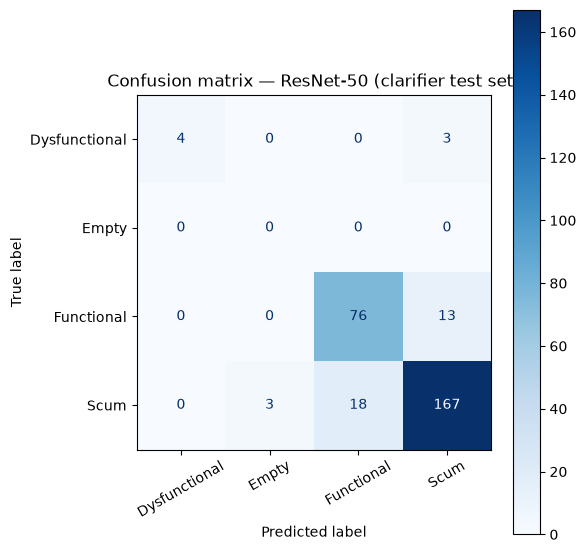

               precision    recall  f1-score   support

Dysfunctional      1.000     0.571     0.727         7
        Empty      0.000     0.000     0.000         0
   Functional      0.809     0.854     0.831        89
         Scum      0.913     0.888     0.900       188

     accuracy                          0.870       284
    macro avg      0.680     0.578     0.615       284
 weighted avg      0.882     0.870     0.874       284

  [warn] 'Empty' has 0 examples in this test set — AUC undefined, skipping.


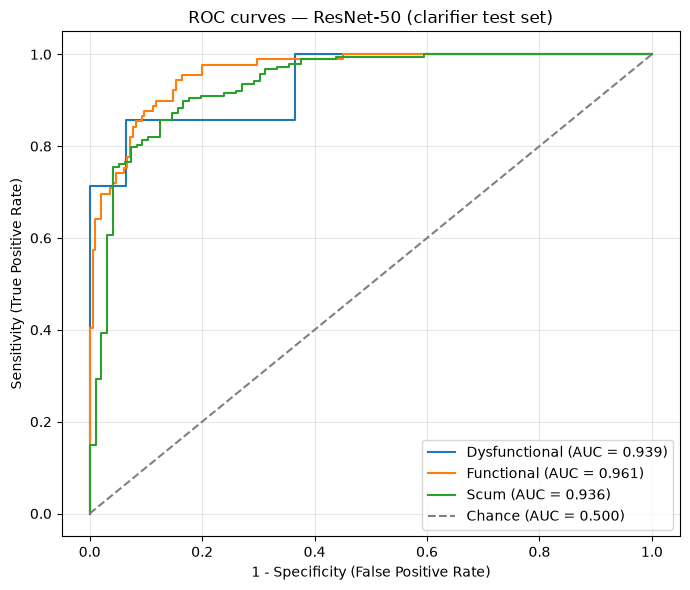

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.939
  Empty          : undefined (0 examples)
  Functional     : 0.961
  Scum           : 0.936

Mean AUC (over 3/4 classes with test examples): 0.945


(np.float64(0.8697183098591549),
 {'Dysfunctional': 0.9386281588447654,
  'Empty': nan,
  'Functional': 0.9610486891385769,
  'Scum': 0.9355053191489362})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/clarifier_aug/results_clarifier_resnet50_Waterval.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
